In [602]:
import pandas as pd

listColors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
data = pd.read_csv('mood_tracking_merged.csv')

In [603]:
import matplotlib.pyplot as plt

# Function to plot horizontal bar charts for multiple choice questions
def plot_multiple_barh(column, column_name, title):
    fig, ax = plt.subplots()
    hbars = ax.barh(column.index, column.values, label=column_name, color=listColors)
    ax.bar_label(hbars, label_type='edge', padding=3)
    plt.title(title)
    plt.show()

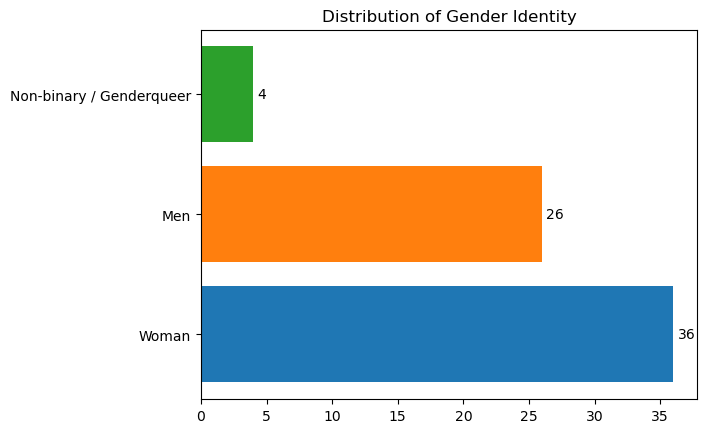

In [604]:
# Extract data regarding the gender of the participants
gender = data['Gender Identity'].value_counts()
plot_multiple_barh(gender,'Gender Identity','Distribution of Gender Identity')

In [605]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pie_chart(column, title, angle):
    labels = column.index.tolist()
    values = column.values.tolist()

    fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(aspect="equal"))
    slices, texts, autotexts = ax.pie(values, 
                                      autopct='%1.1f%%', 
                                      textprops=dict(color="w", weight="bold"),
                                      startangle=angle)

    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")

    for i, p in enumerate(slices):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        
        # Label esterno: solo Nome Categoria e Numero Assoluto
        display_text = f"{labels[i]}: {values[i]}"
        ax.annotate(display_text, xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                    horizontalalignment=horizontalalignment, **kw)

    ax.set_title(title)
    plt.show()

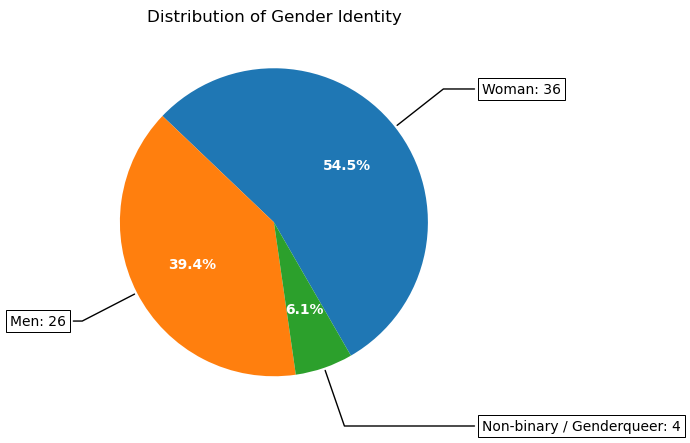

In [606]:
import matplotlib.pyplot as plt
import numpy as np

gender = data['Gender Identity'].value_counts()
plot_pie_chart(gender, 'Distribution of Gender Identity', -60)

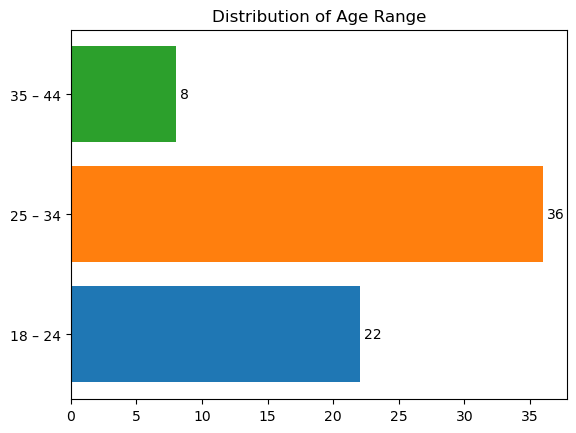

In [607]:
# Extract data regarding the gender of the participants
age = data['Age Range'].value_counts()
age.sort_index(inplace=True)
plot_multiple_barh(age,'Age Range','Distribution of Age Range')

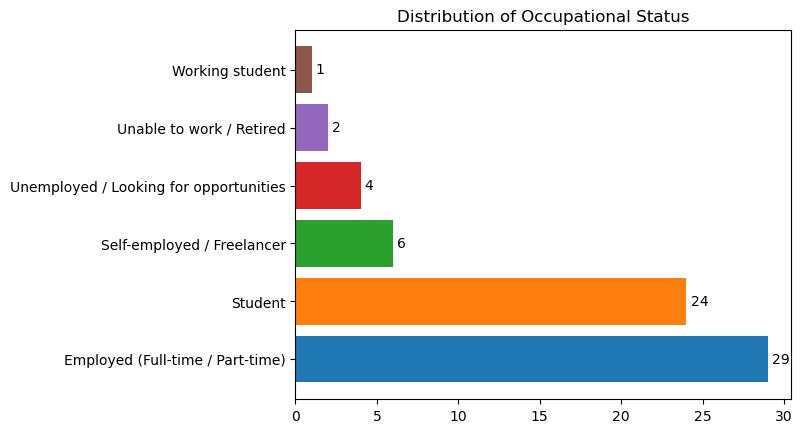

In [608]:
# Extract data regarding the occupational status of the participants
job = data['What is your current occupational status?'].value_counts()
plot_multiple_barh(job,'Occupational Status','Distribution of Occupational Status')

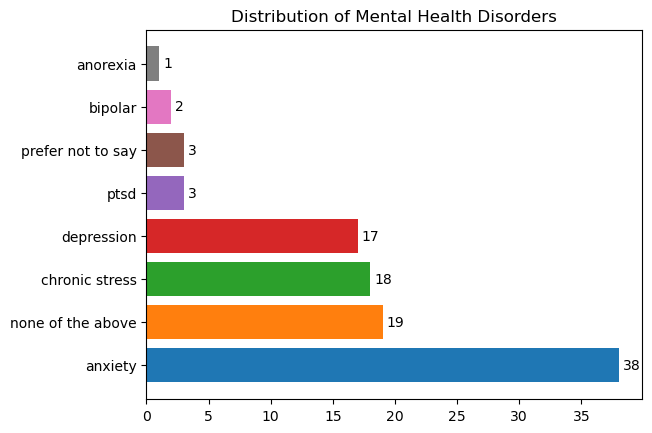

In [609]:
# Extract data regarding the occupational status of the participants
column_name = 'Have you ever experienced, or do you currently struggle with any of the following? (Select all that apply)'
disorders_counts = (data[column_name]
                    .str.lower()           
                    .str.split(',')        
                    .explode()             
                    .str.strip()           
                    .value_counts()) 
plot_multiple_barh(disorders_counts,'Mental Health Disorders','Distribution of Mental Health Disorders')

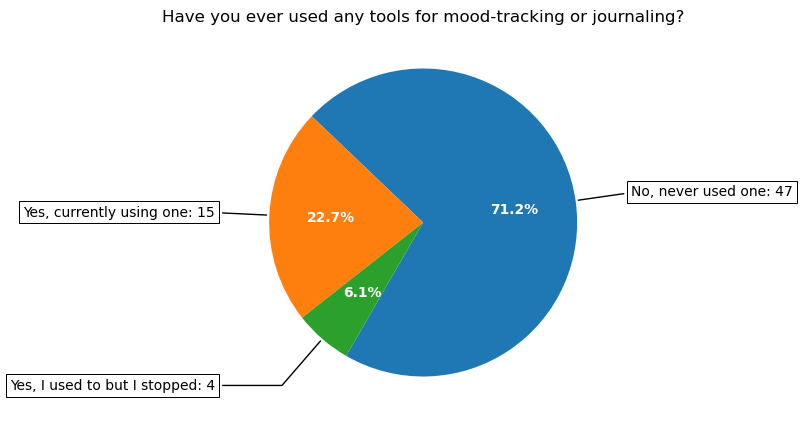

In [610]:
import matplotlib.pyplot as plt
import numpy as np

job = data['Have you ever used any tools for mood-tracking or journaling?'].value_counts()
plot_pie_chart(job, 'Have you ever used any tools for mood-tracking or journaling?', angle=-120)

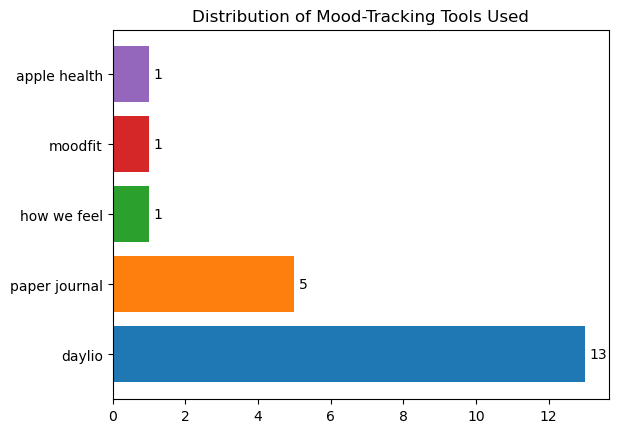

In [611]:
# Extract data regarding the occupational status of the participants
column_name = 'If you answered "Yes", which specific tool(s) did you use? (e.g., Daylio, Notion, Paper Journal, etc.)'
mapping = {
    "i used a paper journal": "paper journal",
    '"how we feel" app': "how we feel",
}

disorders_counts = (data[column_name]
                    .str.lower()
                    .str.split(',')
                    .explode()
                    .str.strip()
                    .replace(mapping) 
                    .value_counts())
plot_multiple_barh(disorders_counts,'Mood-Tracking Tools','Distribution of Mood-Tracking Tools Used')

In [612]:
import matplotlib.pyplot as plt
import textwrap

# Function to plot grouped bar charts for Likert scale questions
def plot_multiple_barh(questions):
    filtered_cols = [col for col in data.columns if col in questions]
    df_melted = data[filtered_cols].melt(var_name='Question', value_name='Response')
    likert_order = ["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"]
    summary_table = pd.crosstab(df_melted['Question'], df_melted['Response'])
    summary_table = summary_table.reindex(columns=likert_order).fillna(0).astype(int)

    for question in summary_table.index:
        plt.figure(figsize=(8, 5))
        
        values = summary_table.loc[question]
        bars = plt.bar(values.index, values.values, color=listColors, edgecolor='black', alpha=0.8)
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom', fontweight='bold')

        wrapped_title = textwrap.fill(question, width=70)
        plt.title(wrapped_title, fontsize=12, pad=20, fontweight='bold')
        
        plt.ylabel("Number of Responses")
        plt.ylim(0, max(values.values) + 2)
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

This section plots the results of users with experince with mood tracking apps, who uses/has used in the past. Open end questions will not be ploted, they will be interepreted aside with the interviews. 

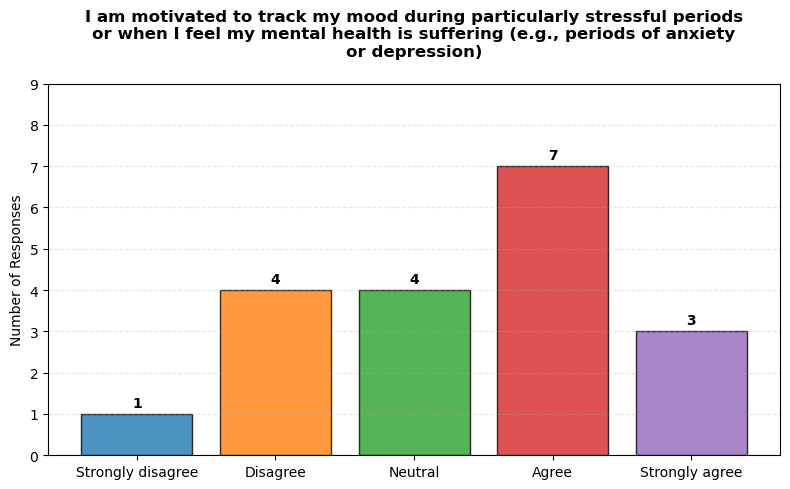

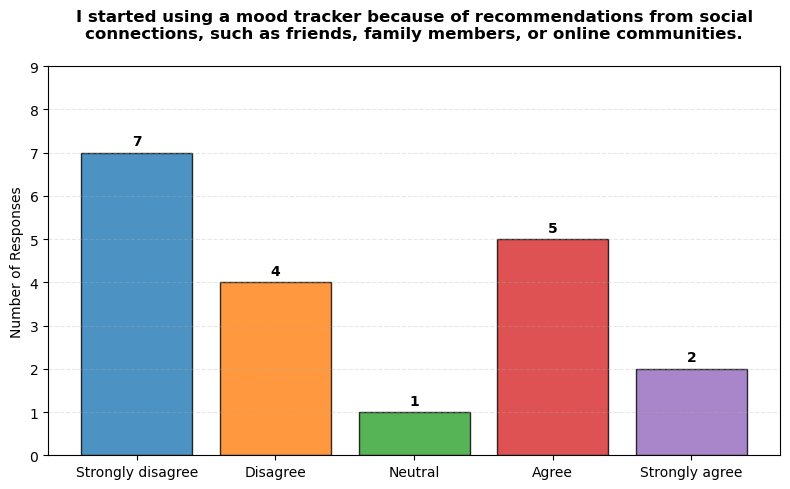

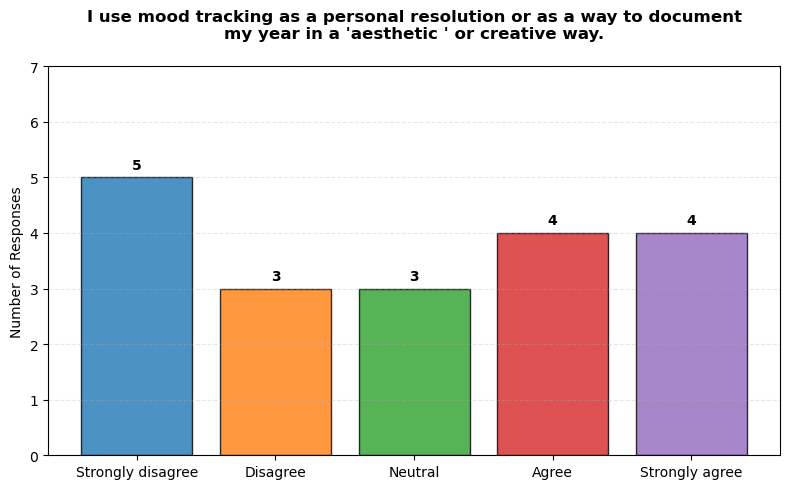

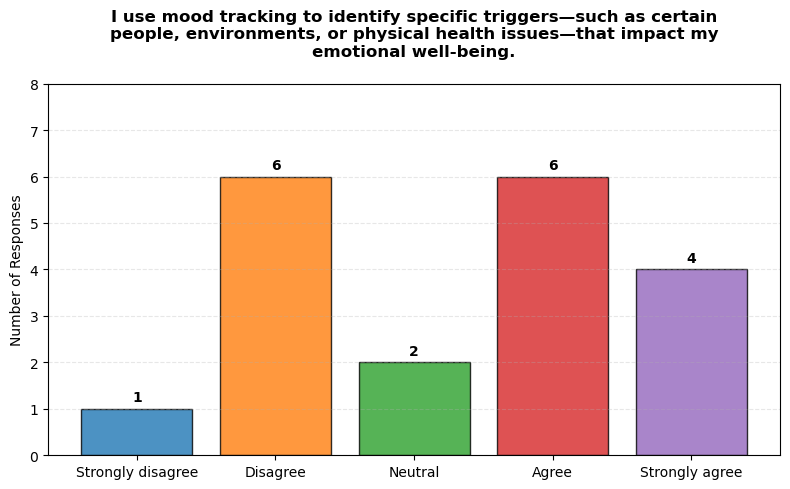

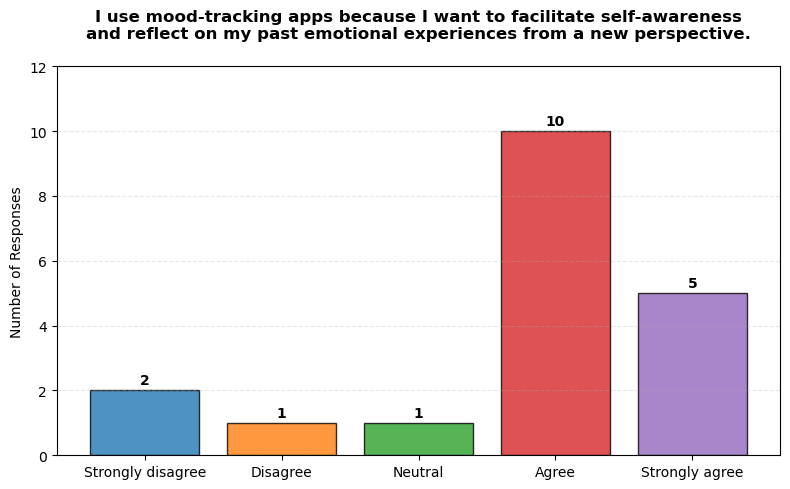

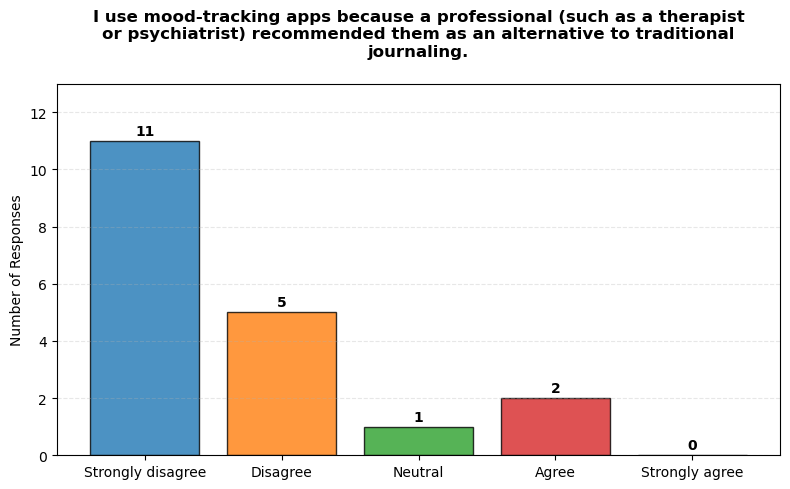

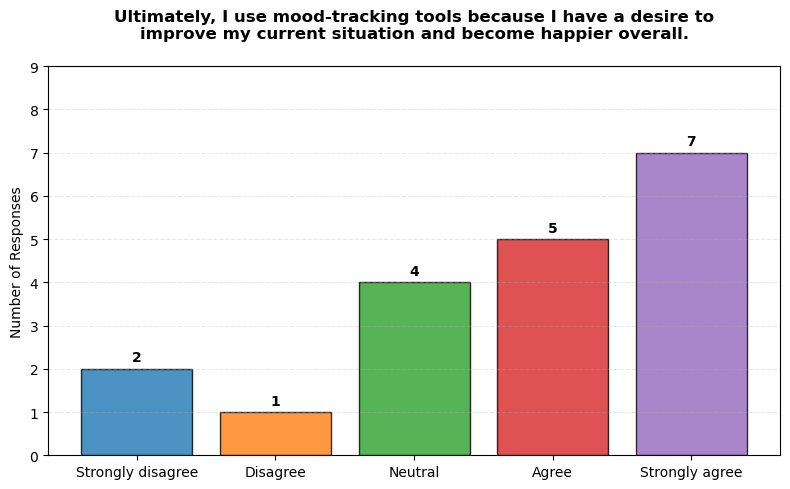

In [613]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

questions = [
    "I am motivated to track my mood during particularly stressful periods or when I feel my mental health is suffering (e.g., periods of anxiety or depression)",
    "I use mood-tracking apps because I want to facilitate self-awareness and reflect on my past emotional experiences from a new perspective.",
    "I use mood tracking to identify specific triggers—such as certain people, environments, or physical health issues—that impact my emotional well-being.",
    "I started using a mood tracker because of recommendations from social connections, such as friends, family members, or online communities.",
    "I use mood-tracking apps because a professional (such as a therapist or psychiatrist) recommended them as an alternative to traditional journaling.",
    "I use mood tracking as a personal resolution or as a way to document my year in a 'aesthetic ' or creative way.",
    "Ultimately, I use mood-tracking tools because I have a desire to improve my current situation and become happier overall."
]

#Plotting the results
plot_multiple_barh(questions)


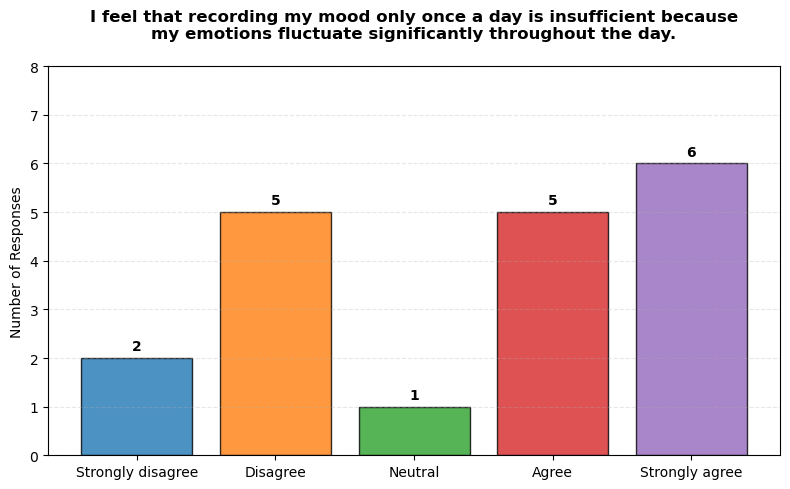

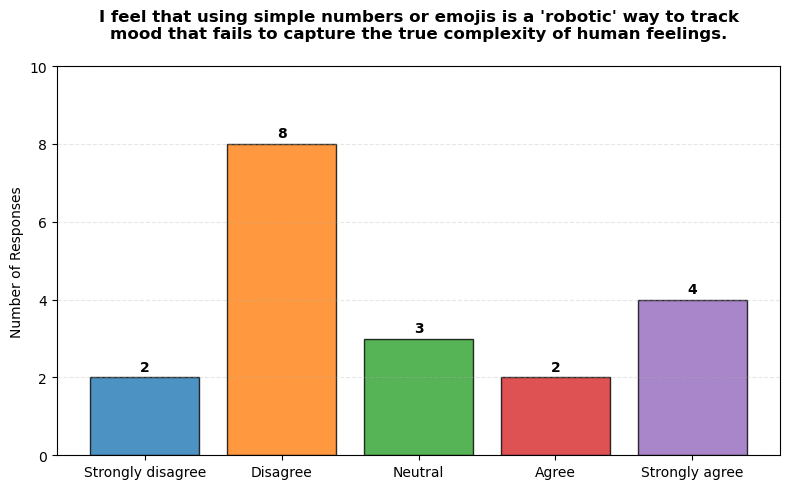

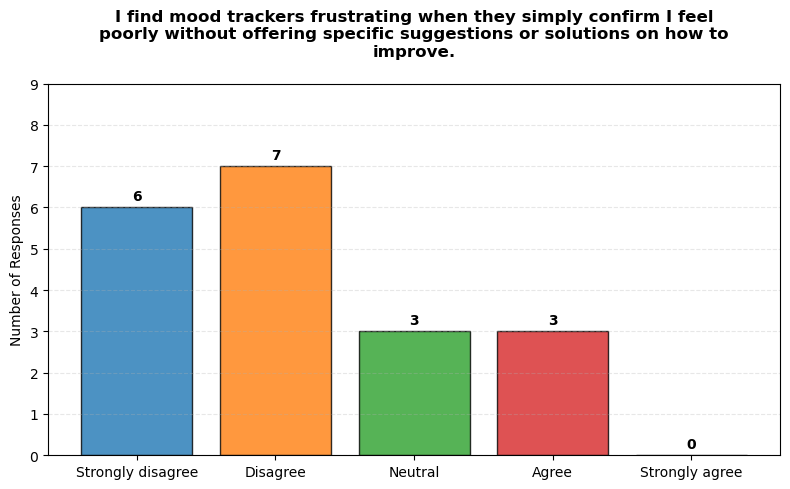

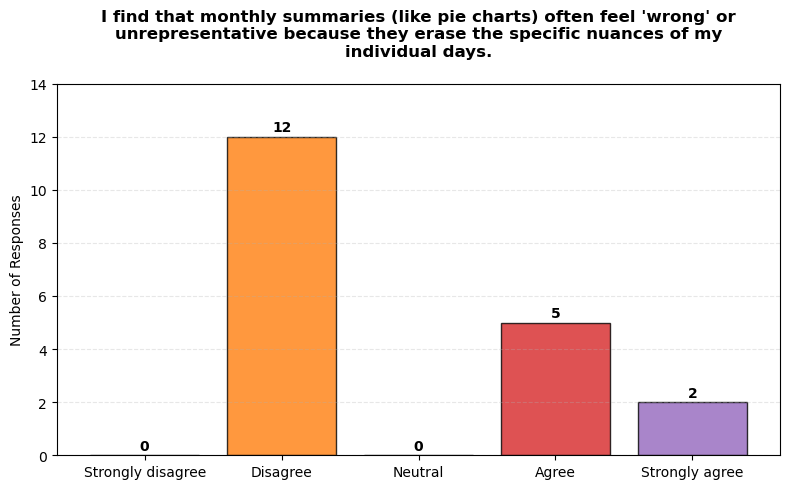

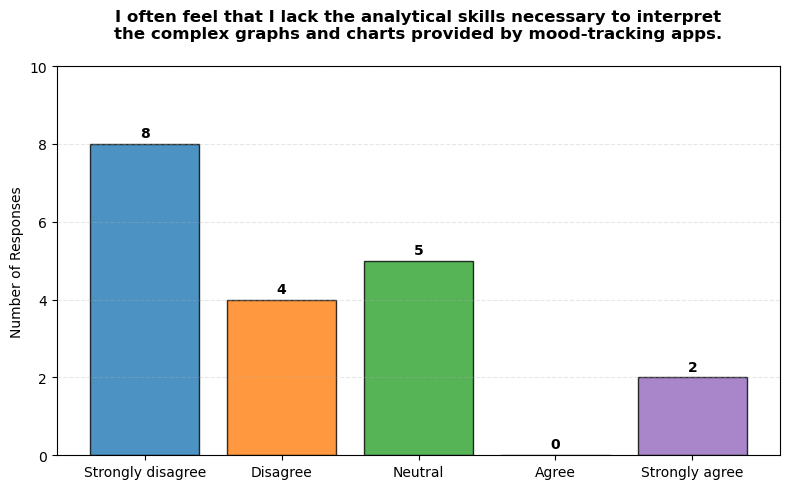

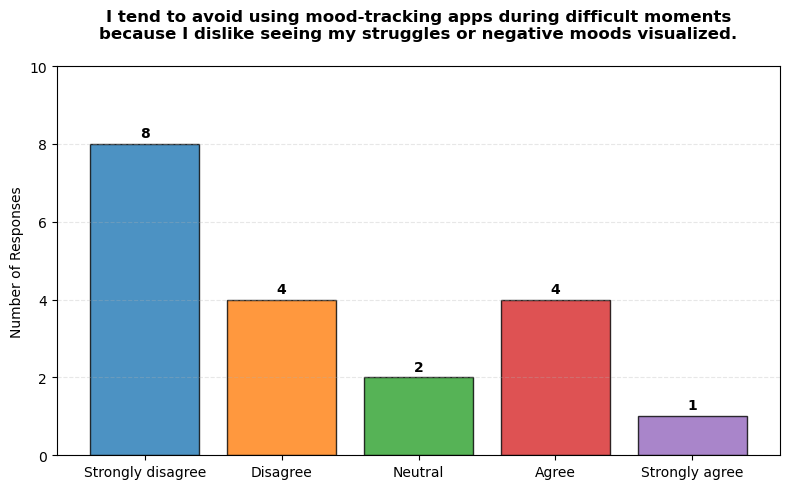

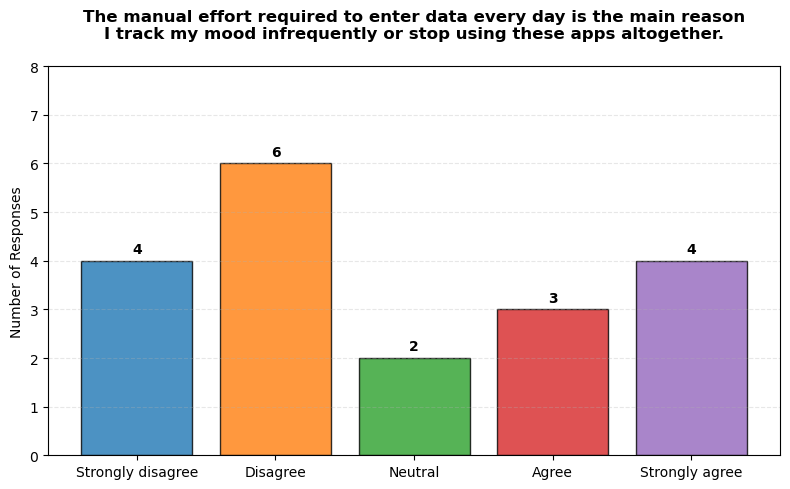

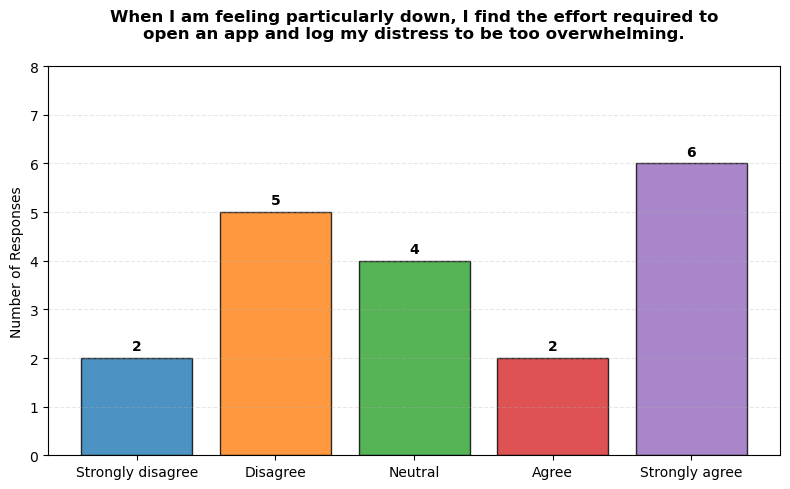

In [614]:
import pandas as pd

questions = [
    "I tend to avoid using mood-tracking apps during difficult moments because I dislike seeing my struggles or negative moods visualized.",
    "When I am feeling particularly down, I find the effort required to open an app and log my distress to be too overwhelming.",
    "I find mood trackers frustrating when they simply confirm I feel poorly without offering specific suggestions or solutions on how to improve.",
    "I often feel that I lack the analytical skills necessary to interpret the complex graphs and charts provided by mood-tracking apps.",
    "I feel that recording my mood only once a day is insufficient because my emotions fluctuate significantly throughout the day.",
    "I feel that using simple numbers or emojis is a 'robotic' way to track mood that fails to capture the true complexity of human feelings.",
    "I find that monthly summaries (like pie charts) often feel 'wrong' or unrepresentative because they erase the specific nuances of my individual days.",
    "The manual effort required to enter data every day is the main reason I track my mood infrequently or stop using these apps altogether."
]

#Plotting the results
plot_multiple_barh(questions)


This section plots teh responces of people who never used mood tracking apps. 

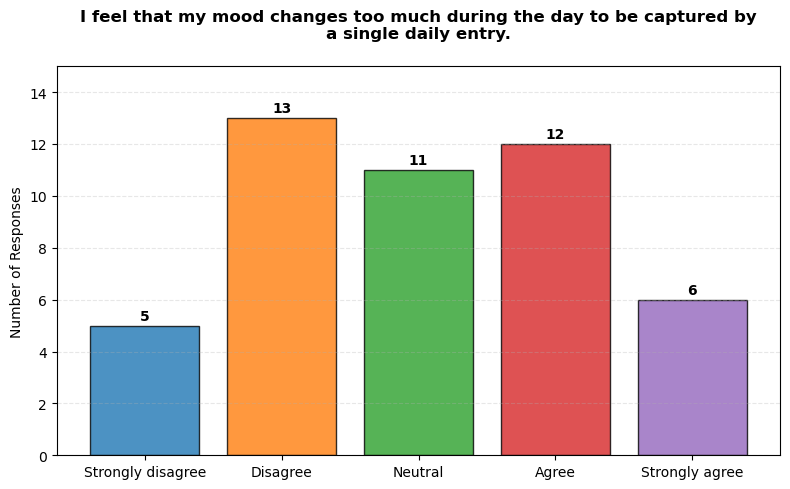

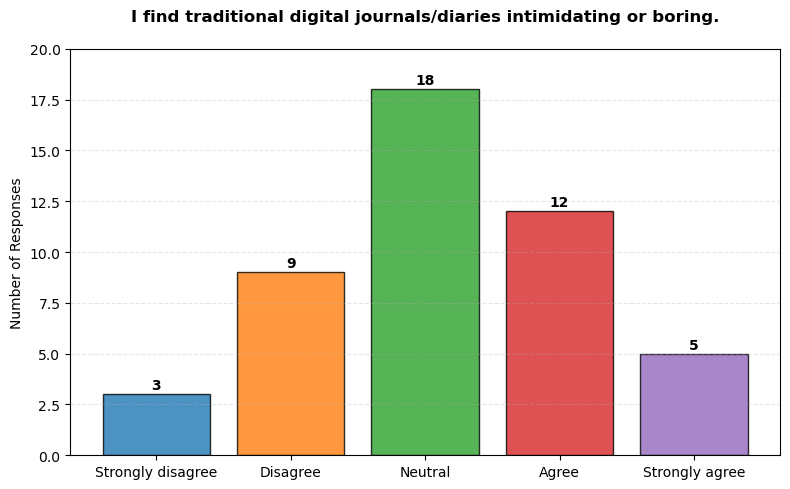

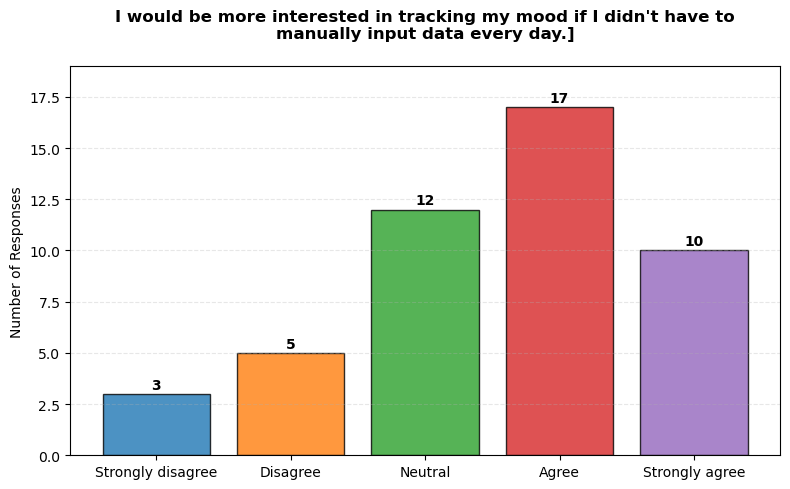

In [615]:
import pandas as pd

questions = [
    "I would be more interested in tracking my mood if I didn't have to manually input data every day.]",
       'I feel that my mood changes too much during the day to be captured by a single daily entry.',
       'I find traditional digital journals/diaries intimidating or boring.'
]

#Plotting the results
plot_multiple_barh(questions)


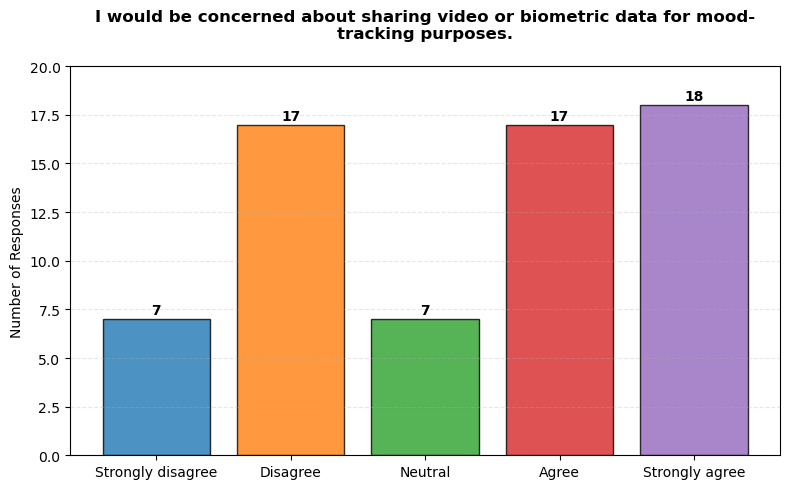

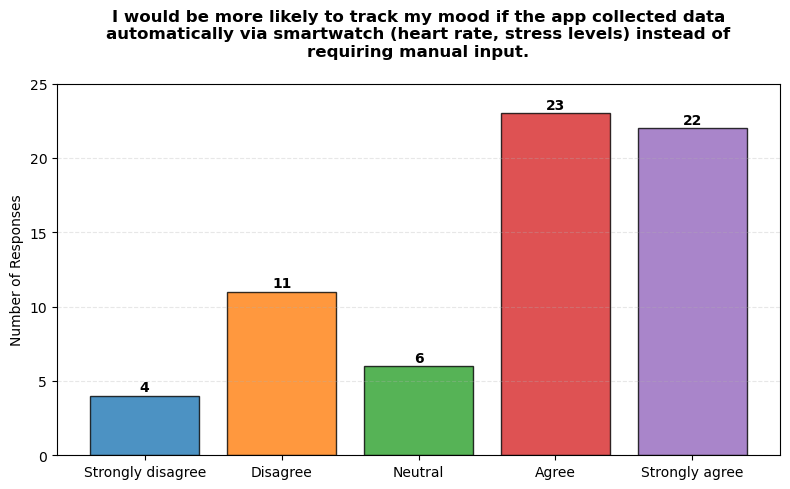

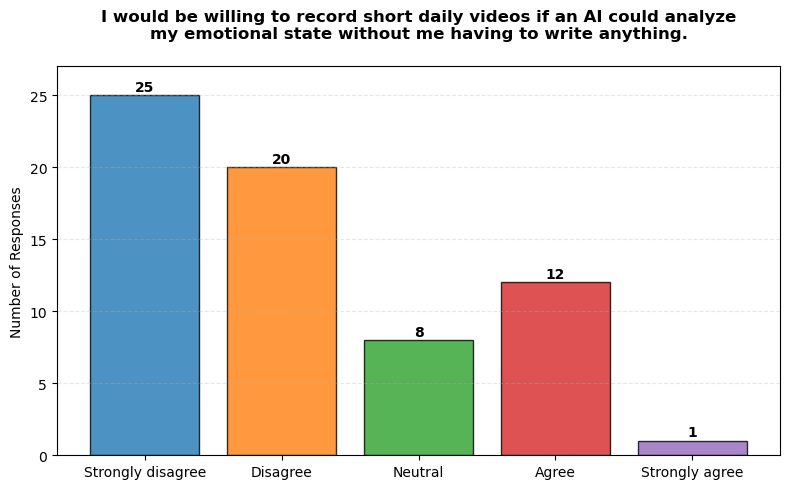

In [616]:
import pandas as pd

questions = [
    "I would be more likely to track my mood if the app collected data automatically via smartwatch (heart rate, stress levels) instead of requiring manual input.",
       "I would be willing to record short daily videos if an AI could analyze my emotional state without me having to write anything.",
       "I would be concerned about sharing video or biometric data for mood-tracking purposes."
]

#Plotting the results
plot_multiple_barh(questions)
